# High Multicollinearity Experiment

Este notebook avalia o cenário de forte dependência linear entre as variáveis explicativas (=150, p=50$), gerado com posto efetivo reduzido (effective_rank=5, tail_strength=0.1) e 12 variáveis informativas.

**Objetivo:** Analisar a instabilidade e inflação de variância do OLS sob multicolinearidade severa, comparando como a regularização $ (Ridge) estabiliza a estimação e como o Elastic Net agrupa variáveis correlacionadas superando a seleção arbitrária do LASSO.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import data generation
from data_generation.generate_data import generate_data

# Import plots
from plots.coefficient_plot import coefficient_plot
from plots.metrics import compute_metrics

# Import models
from models.OLS import run_ols
from models.LASSO import run_lasso, run_lasso_cv
from models.Ridge import run_ridge, run_ridge_cv
from models.ElasticNet import run_elasticnet_alpha, run_elasticnet_l1ratio, run_elasticnet_cv

# Removing Warnings
import warnings


In [2]:
warnings.filterwarnings('ignore')

## 1. Generating Data

GENERATED DATA:
Shape of X: (100, 500)

X Matrix: 
 [[-0.72549012 -0.04816863  1.86529599 ... -0.02349424 -0.12664455
   1.21448087]
 [ 1.43615851  1.32986834  0.44693531 ... -0.45198375 -0.31175334
   1.10134504]
 [-0.00288618  0.59895795  0.33323047 ... -1.05684666  0.1177757
   0.27434477]
 ...
 [-0.55279092 -0.4350526   1.81052248 ...  1.50831075  0.68871274
   1.40431628]
 [-0.61441548  0.35952316 -0.50456053 ...  0.10032296 -1.30667933
   1.13242311]
 [-0.68722814 -1.72729518  0.15804712 ... -1.61274037 -0.70935004
   0.67624818]]
Shape of y: (100,)

y Vector: 
 [ 100.53499214 -141.27306177  275.03049962  166.90351319  -93.63350529
  218.46775173 -225.15025752 -180.64478029  -27.02406334 -310.3458104
  154.54398601 -199.65283765  -66.38554981  692.05749541  430.6148621
   29.38620161 -203.55093921   11.89034552  -81.74777928  277.52245264
  116.31238477  -24.69830263  153.00707024 -137.42473708 -109.71916128
  -48.88423452  246.93538665 -218.02967222 -612.49508702  161.82429384
 

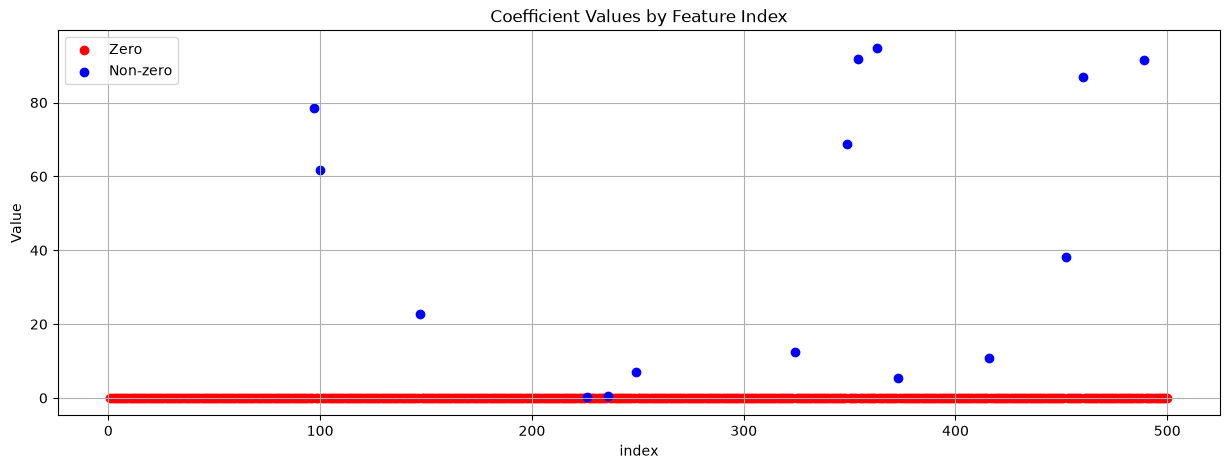

In [ ]:
X_train, X_test, y_train, y_test, coef = generate_data(
    n_samples=150,
    n_features=50,
    n_informative=12,
    noise=2.0,
    effective_rank=5,
    tail_strength=0.1
)

coefficient_plot(coef)


## 2. Ordinary Least Square

MAE: 121.68
MSE: 25137.88
RMSE: 158.55
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6888
Mean coef magnitude: 3.2403


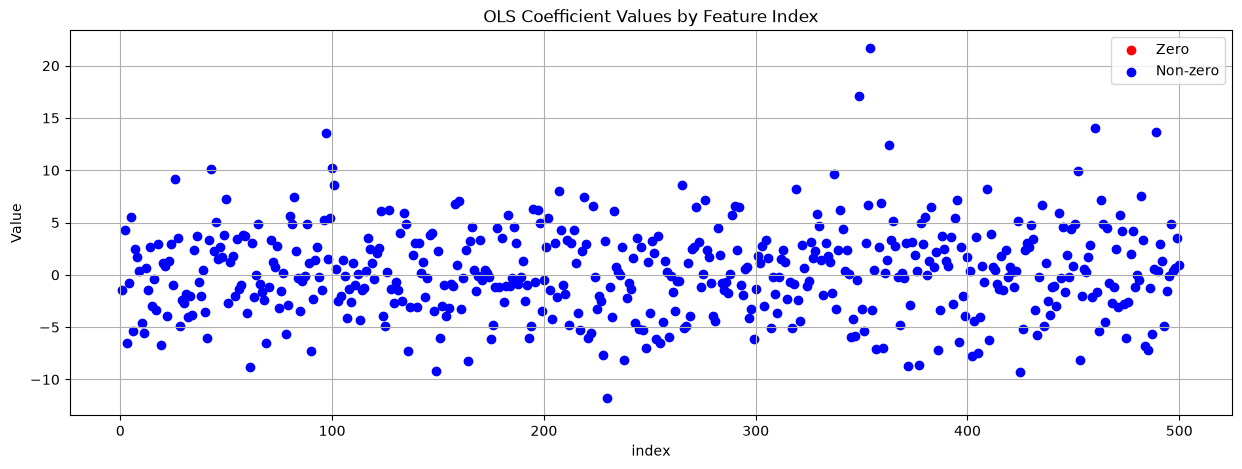

In [4]:
OLS_model = run_ols(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 3. Least Absolute Shrinkage and Selection Operator

Metrics for i = 0.001:
MAE: 204.22
MSE: 75933.68
RMSE: 275.56
R² Score: -2.24
Number of non zero coefs: 500
Max coef magnitude: 61.0317
Mean coef magnitude: 6.6609


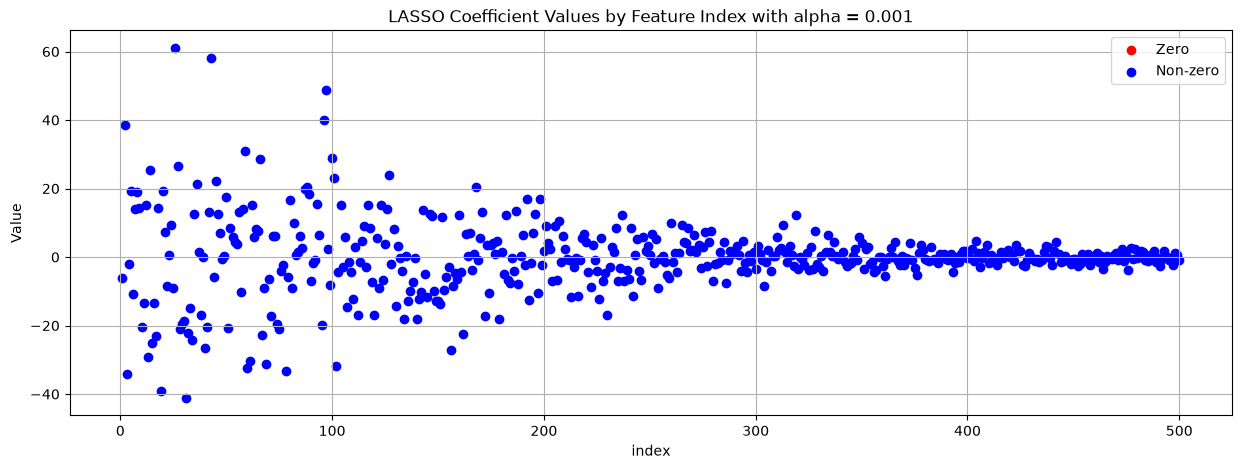

Metrics for i = 0.01:
MAE: 148.08
MSE: 34541.61
RMSE: 185.85
R² Score: -0.48
Number of non zero coefs: 246
Max coef magnitude: 47.2123
Mean coef magnitude: 3.4229


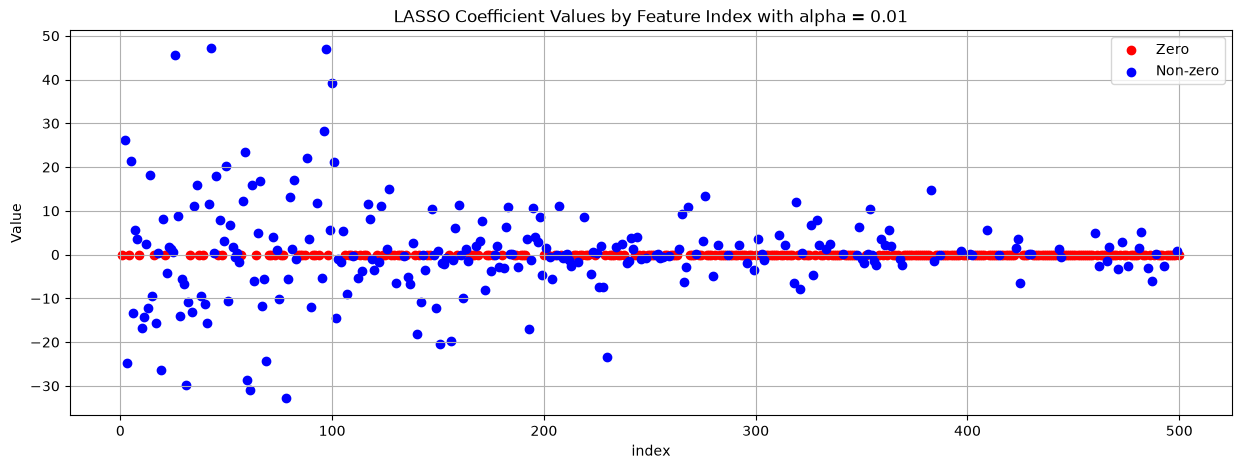

Metrics for i = 0.1:
MAE: 2.78
MSE: 10.16
RMSE: 3.19
R² Score: 1.00
Number of non zero coefs: 65
Max coef magnitude: 98.0319
Mean coef magnitude: 1.3047


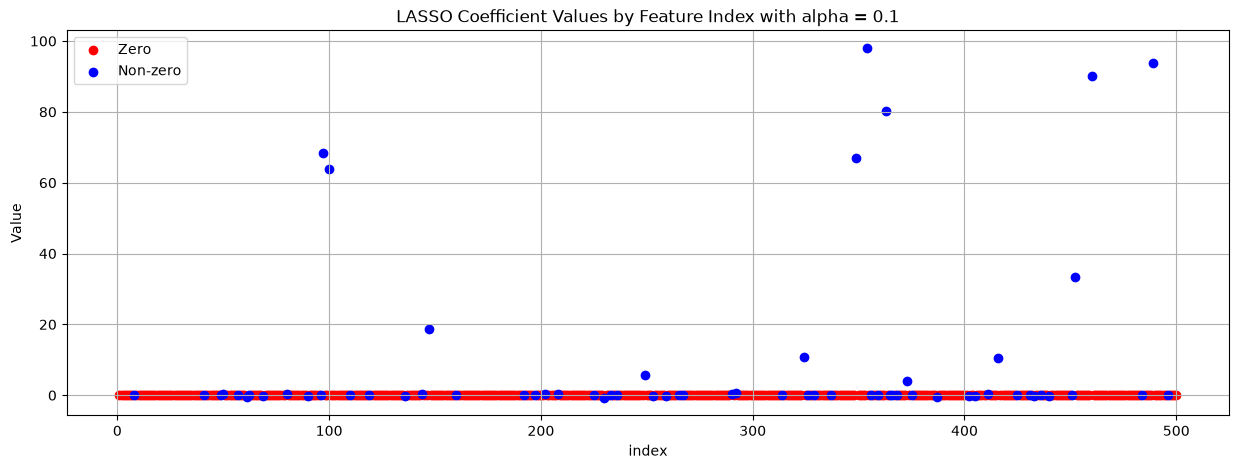

Metrics for i = 1.0:
MAE: 3.90
MSE: 25.28
RMSE: 5.03
R² Score: 1.00
Number of non zero coefs: 23
Max coef magnitude: 97.9885
Mean coef magnitude: 1.2771


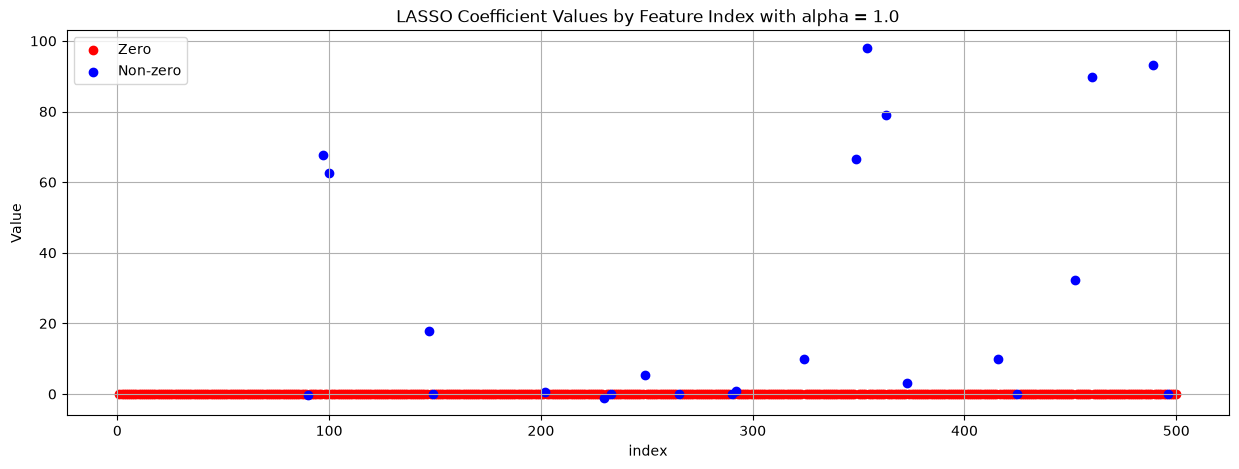

Metrics for i = 10.0:
MAE: 21.79
MSE: 694.73
RMSE: 26.36
R² Score: 0.97
Number of non zero coefs: 13
Max coef magnitude: 94.5894
Mean coef magnitude: 1.0776


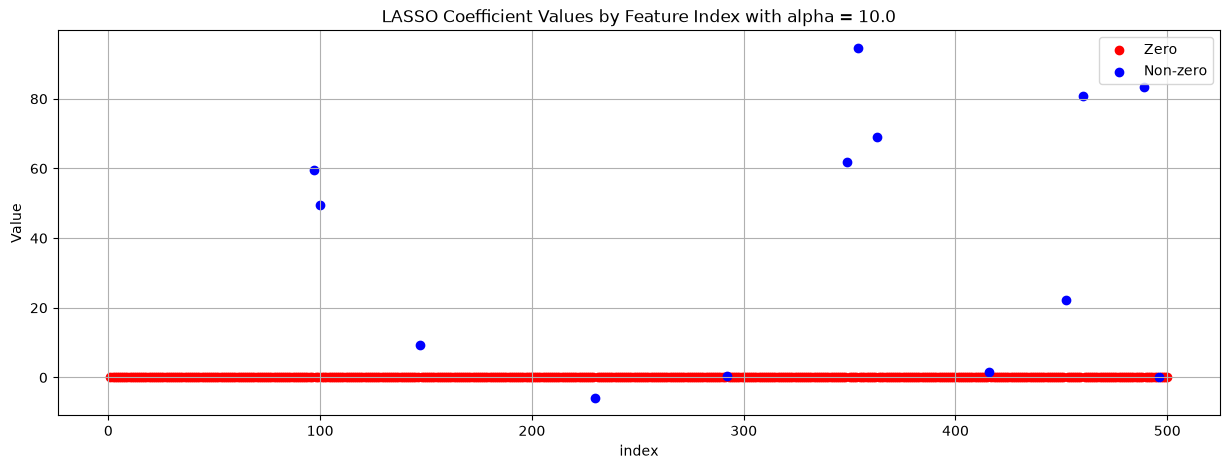

Metrics for i = 100.0:
MAE: 120.42
MSE: 21464.49
RMSE: 146.51
R² Score: 0.08
Number of non zero coefs: 3
Max coef magnitude: 42.3569
Mean coef magnitude: 0.0954


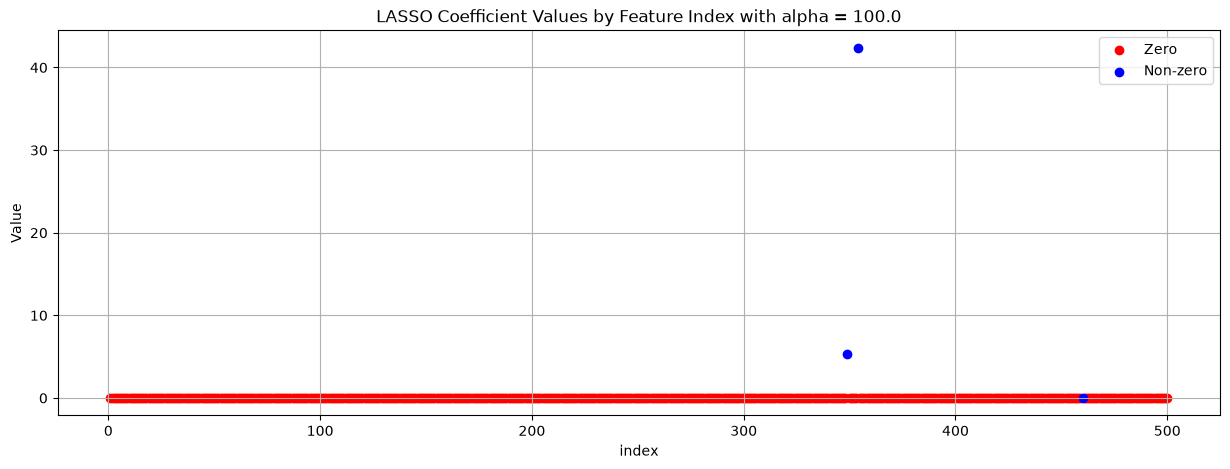

In [5]:
LASSO_models = run_lasso(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha for LASSO

MAE: 2.10
MSE: 6.27
RMSE: 2.50
R² Score: 1.00
Number of non zero coefs: 43
Max coef magnitude: 98.1414
Mean coef magnitude: 1.2998


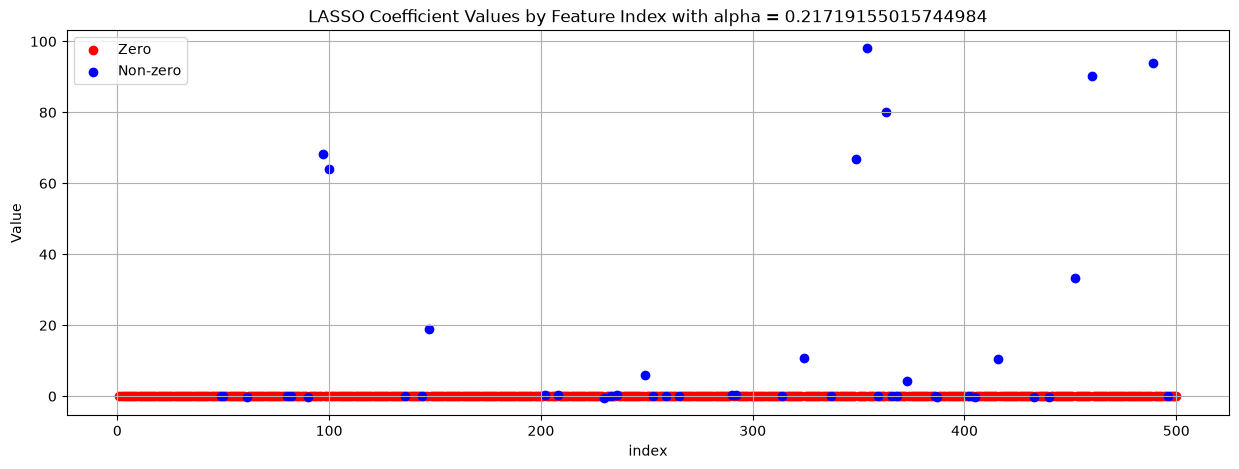

In [6]:
LASSOCV_model = run_lasso_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 4. Ridge

Metrics for i = 0.001:
MAE: 121.68
MSE: 25137.84
RMSE: 158.55
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6888
Mean coef magnitude: 3.2403


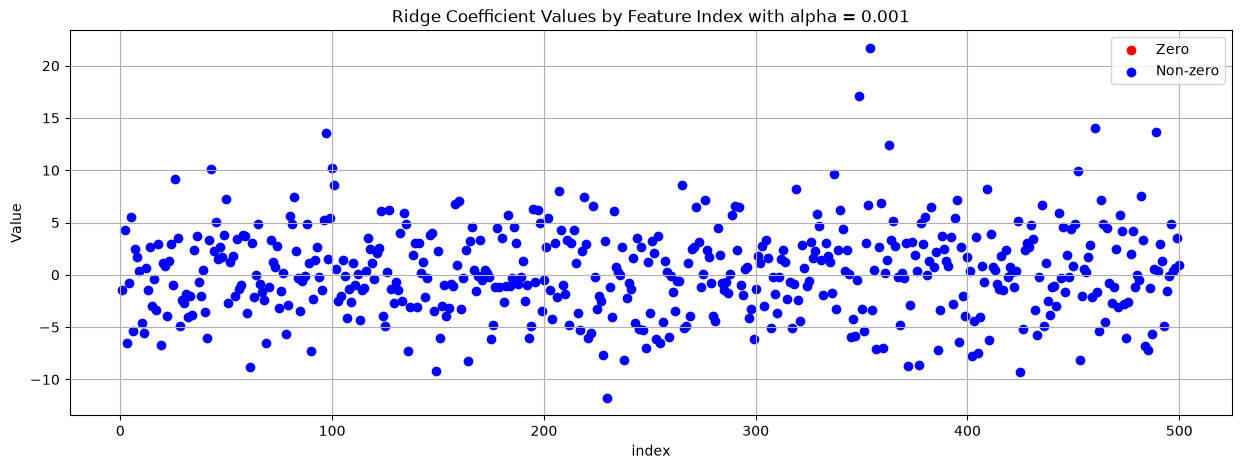

Metrics for i = 0.01:
MAE: 121.67
MSE: 25137.52
RMSE: 158.55
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6883
Mean coef magnitude: 3.2402


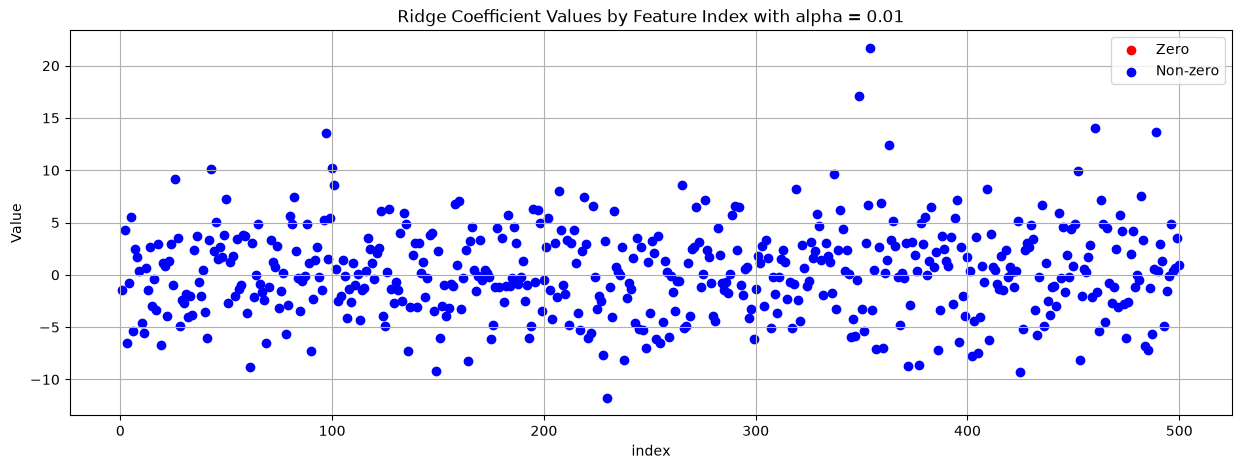

Metrics for i = 0.1:
MAE: 121.66
MSE: 25134.27
RMSE: 158.54
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6839
Mean coef magnitude: 3.2396


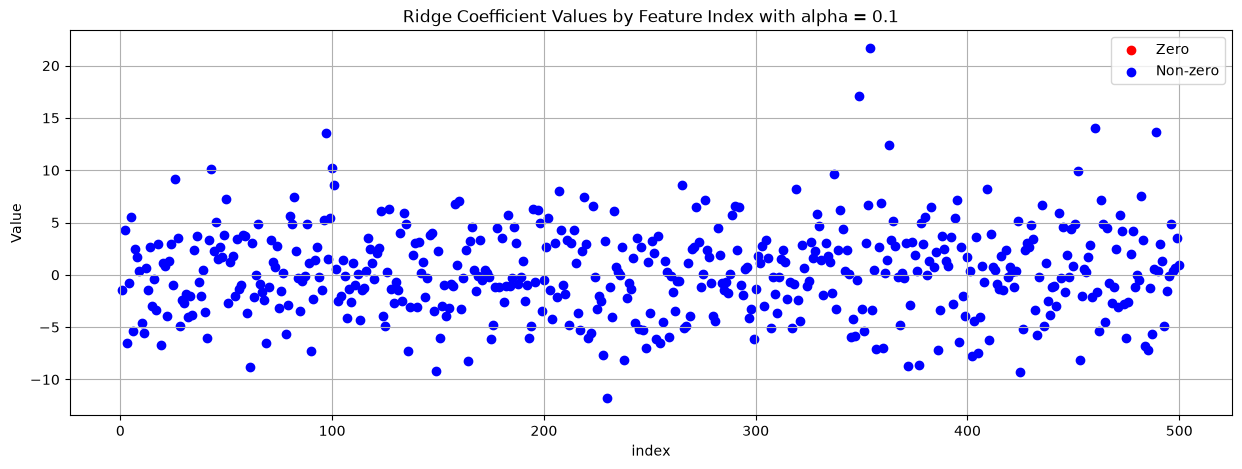

Metrics for i = 1.0:
MAE: 121.54
MSE: 25102.00
RMSE: 158.44
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6402
Mean coef magnitude: 3.2334


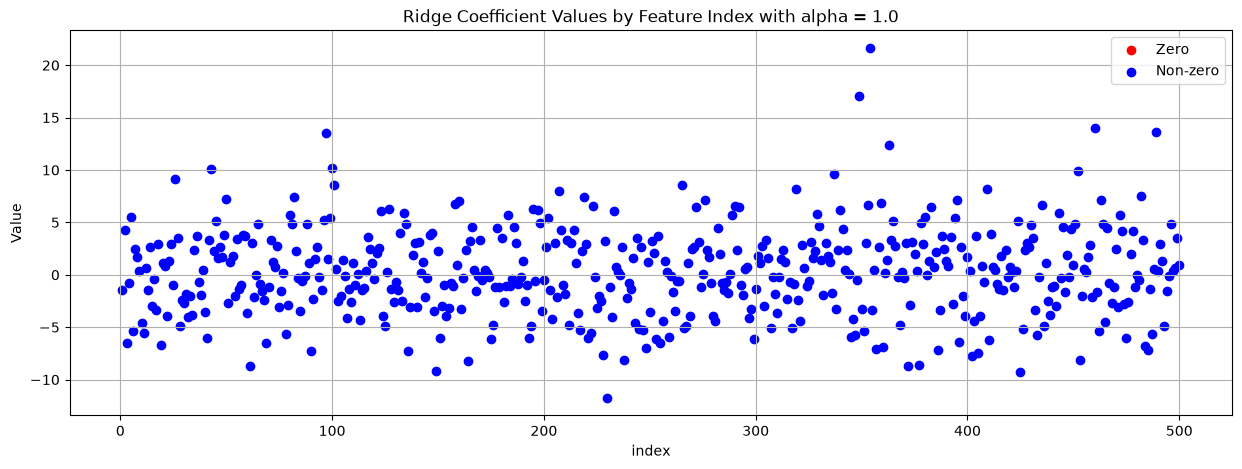

Metrics for i = 10.0:
MAE: 120.37
MSE: 24795.13
RMSE: 157.46
R² Score: -0.06
Number of non zero coefs: 500
Max coef magnitude: 21.2145
Mean coef magnitude: 3.1731


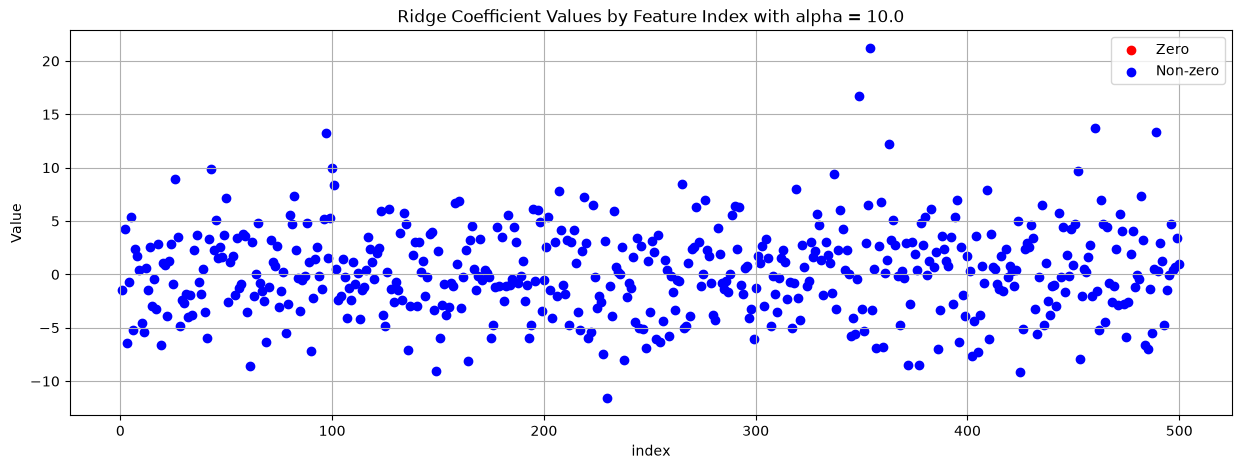

Metrics for i = 100.0:
MAE: 114.91
MSE: 22826.87
RMSE: 151.09
R² Score: 0.02
Number of non zero coefs: 500
Max coef magnitude: 17.8309
Mean coef magnitude: 2.6932


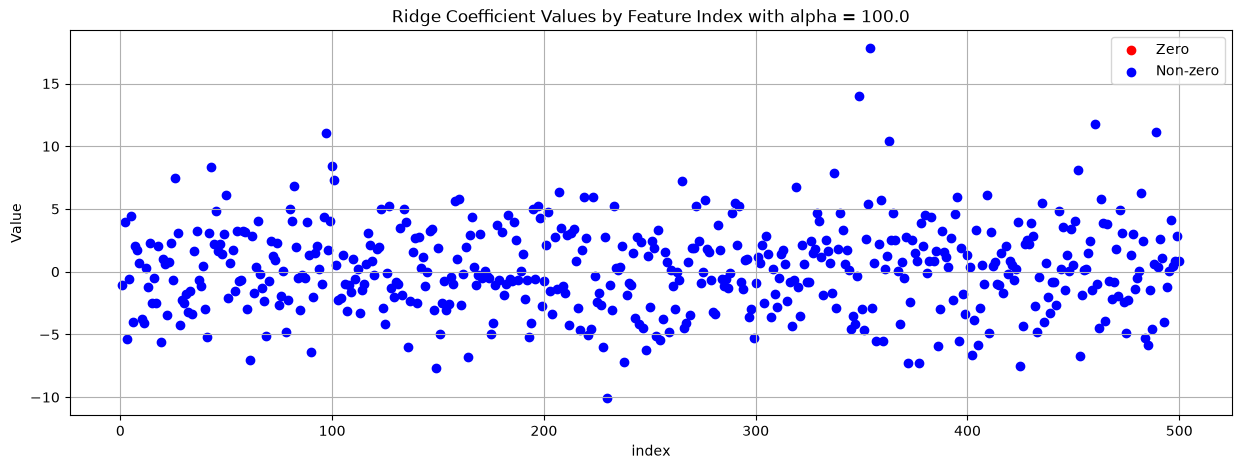

In [7]:
Ridge_models = run_ridge(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Ridge Best Alpha

MAE: 121.66
MSE: 25134.27
RMSE: 158.54
R² Score: -0.07
Number of non zero coefs: 500
Max coef magnitude: 21.6839
Mean coef magnitude: 3.2396


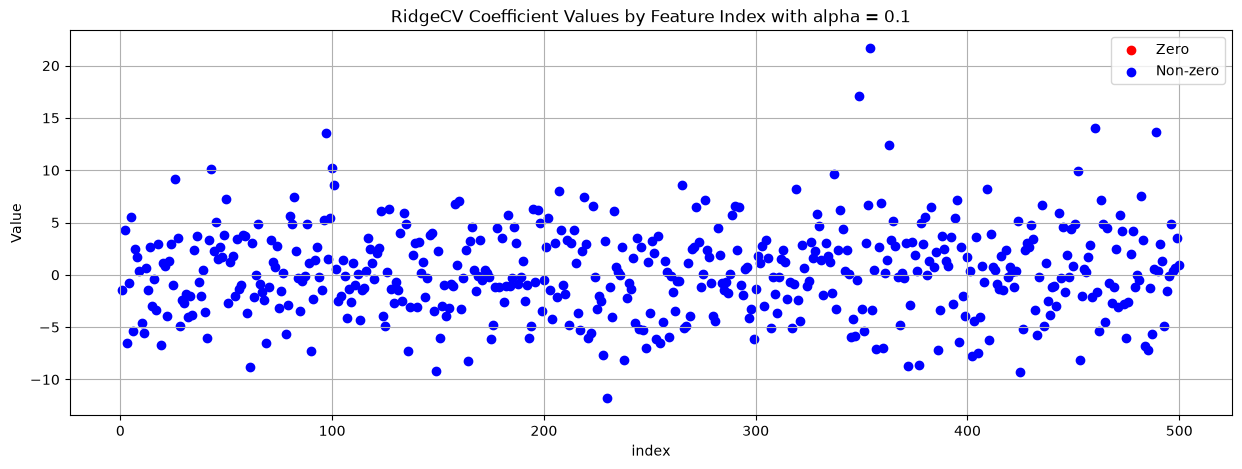

In [8]:
RidgeCV_model = run_ridge_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 5. Elastic Net

Metrics for i = 0.001:
MAE: 158.47
MSE: 37774.84
RMSE: 194.36
R² Score: -0.61
Number of non zero coefs: 490
Max coef magnitude: 36.7370
Mean coef magnitude: 4.5993


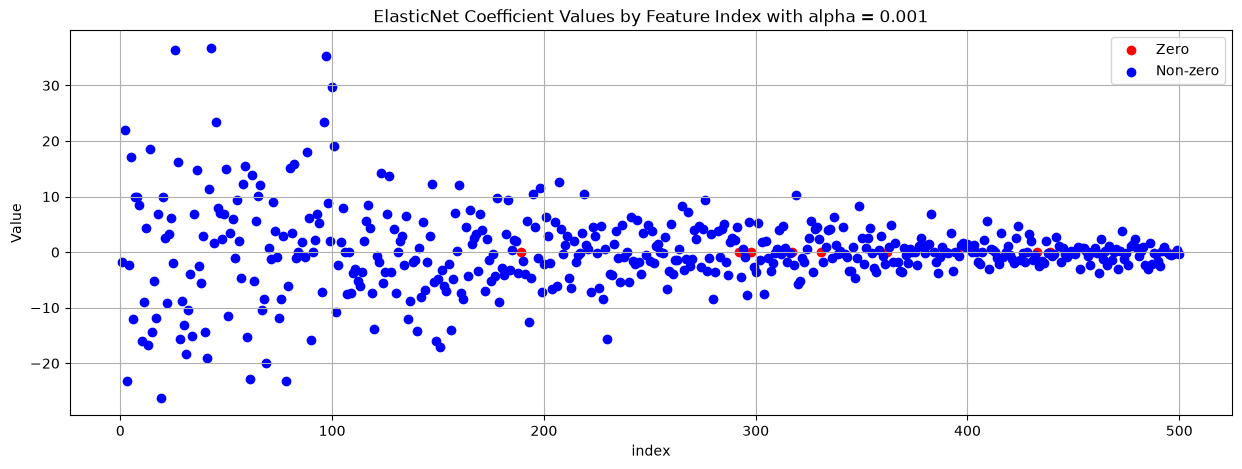

Metrics for i = 0.01:
MAE: 124.05
MSE: 24915.19
RMSE: 157.85
R² Score: -0.06
Number of non zero coefs: 448
Max coef magnitude: 25.6056
Mean coef magnitude: 3.0142


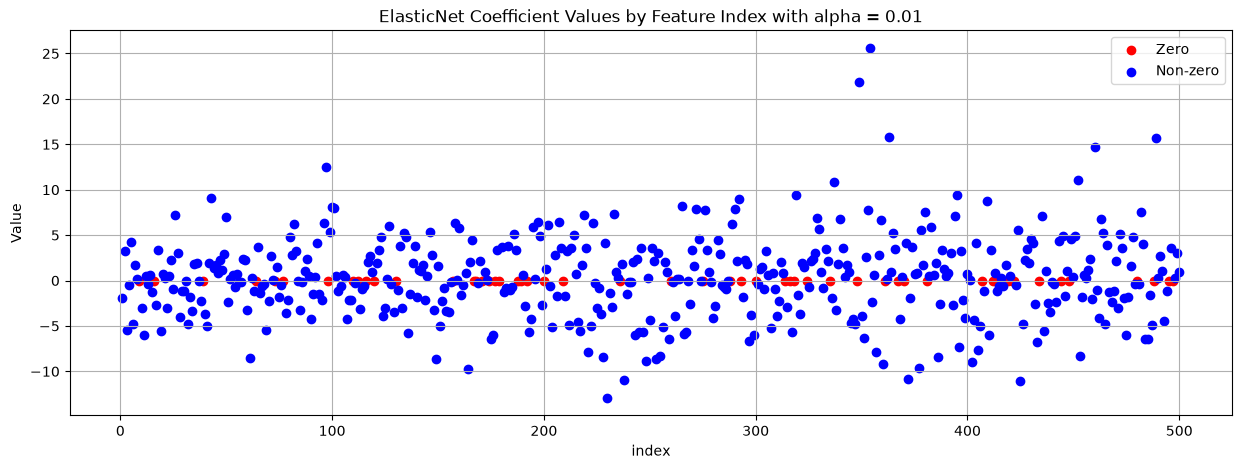

Metrics for i = 0.1:
MAE: 117.27
MSE: 23800.52
RMSE: 154.27
R² Score: -0.02
Number of non zero coefs: 428
Max coef magnitude: 24.1591
Mean coef magnitude: 2.9302


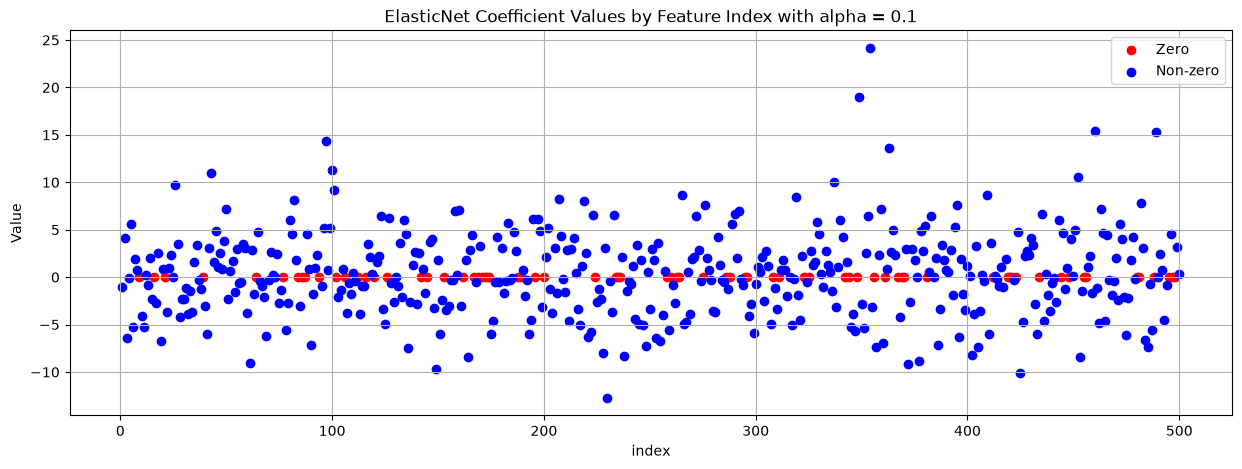

Metrics for i = 1.0:
MAE: 113.71
MSE: 22647.89
RMSE: 150.49
R² Score: 0.03
Number of non zero coefs: 426
Max coef magnitude: 22.3824
Mean coef magnitude: 2.6659


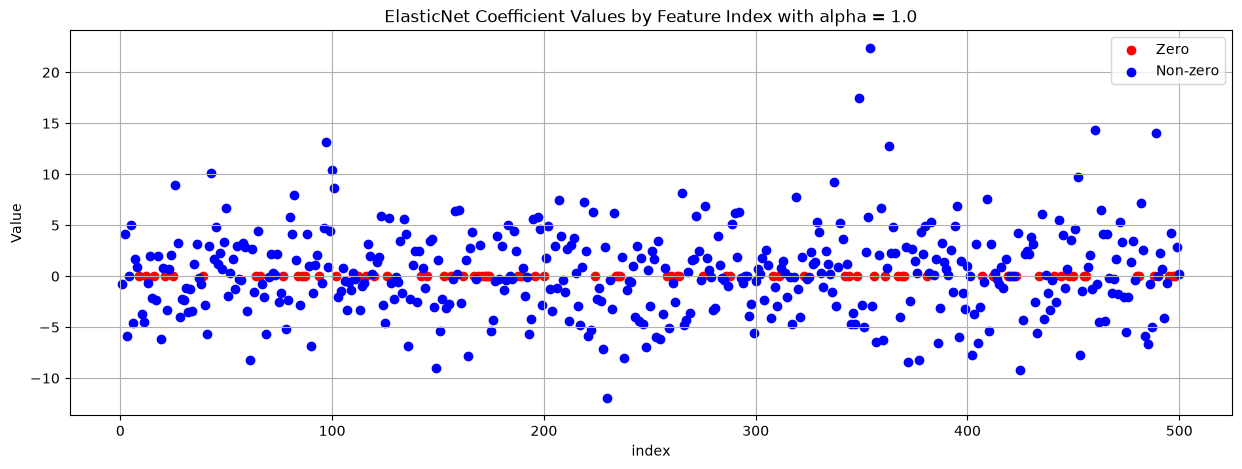

Metrics for i = 10.0:
MAE: 111.11
MSE: 20421.02
RMSE: 142.90
R² Score: 0.13
Number of non zero coefs: 367
Max coef magnitude: 13.0048
Mean coef magnitude: 1.3413


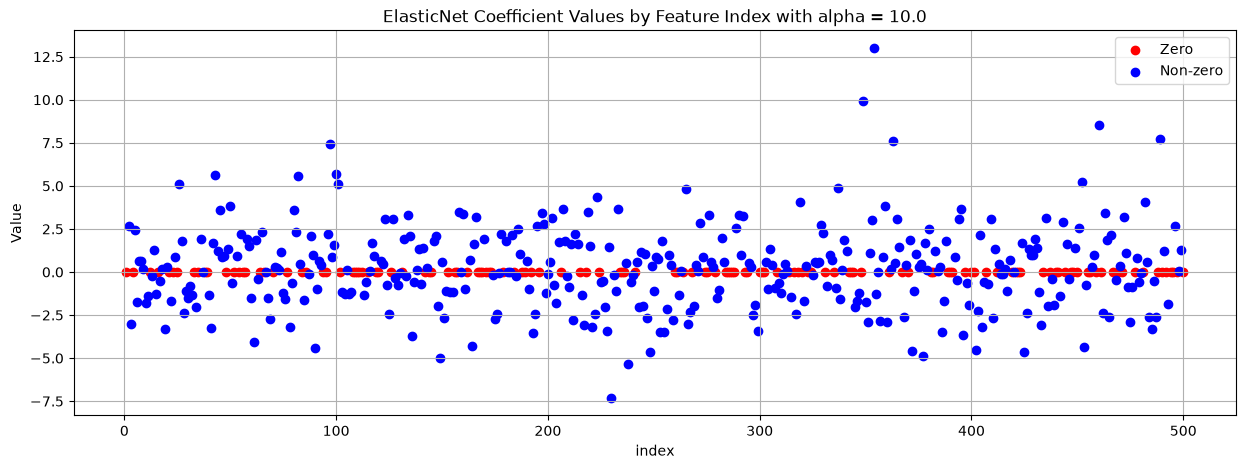

Metrics for i = 100.0:
MAE: 128.38
MSE: 25444.03
RMSE: 159.51
R² Score: -0.09
Number of non zero coefs: 31
Max coef magnitude: 1.7995
Mean coef magnitude: 0.0229


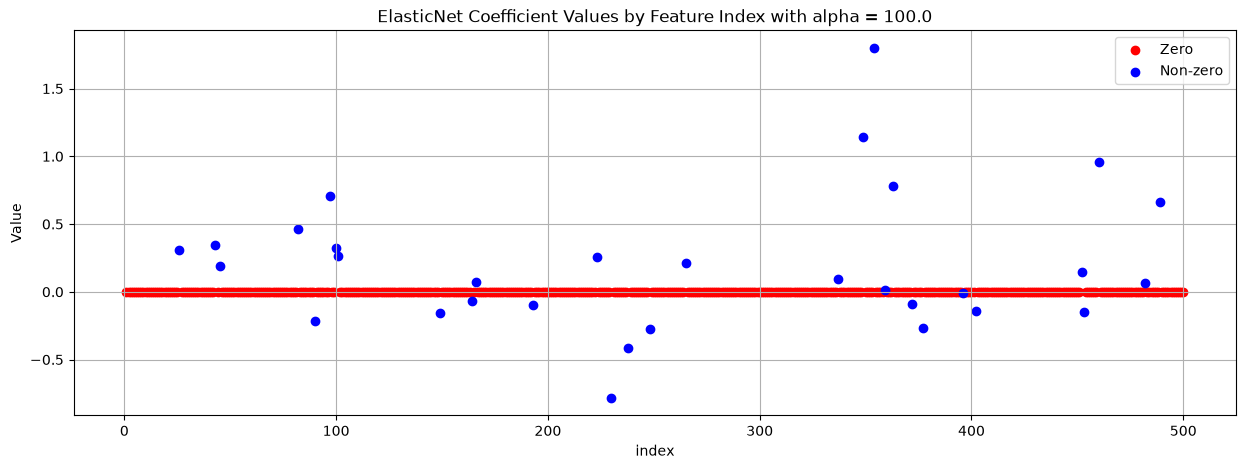

In [9]:
ElasticNet_alpha_models = run_elasticnet_alpha(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

Metrics for i = 0.0:
MAE: 115.78
MSE: 23137.36
RMSE: 152.11
R² Score: 0.01
Number of non zero coefs: 500
Max coef magnitude: 18.4709
Mean coef magnitude: 2.7842


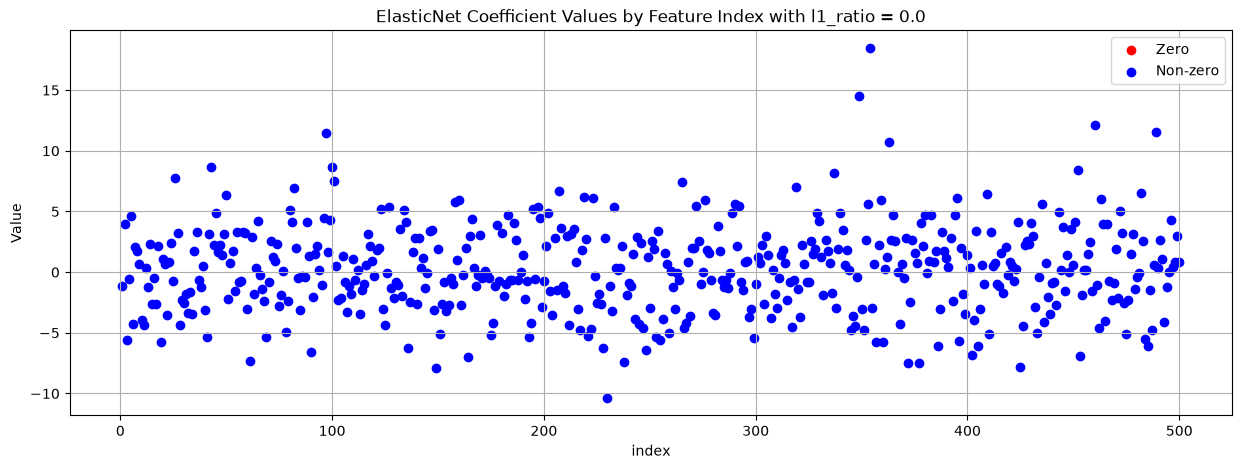

Metrics for i = 0.25:
MAE: 115.20
MSE: 23048.23
RMSE: 151.82
R² Score: 0.02
Number of non zero coefs: 471
Max coef magnitude: 19.9472
Mean coef magnitude: 2.7542


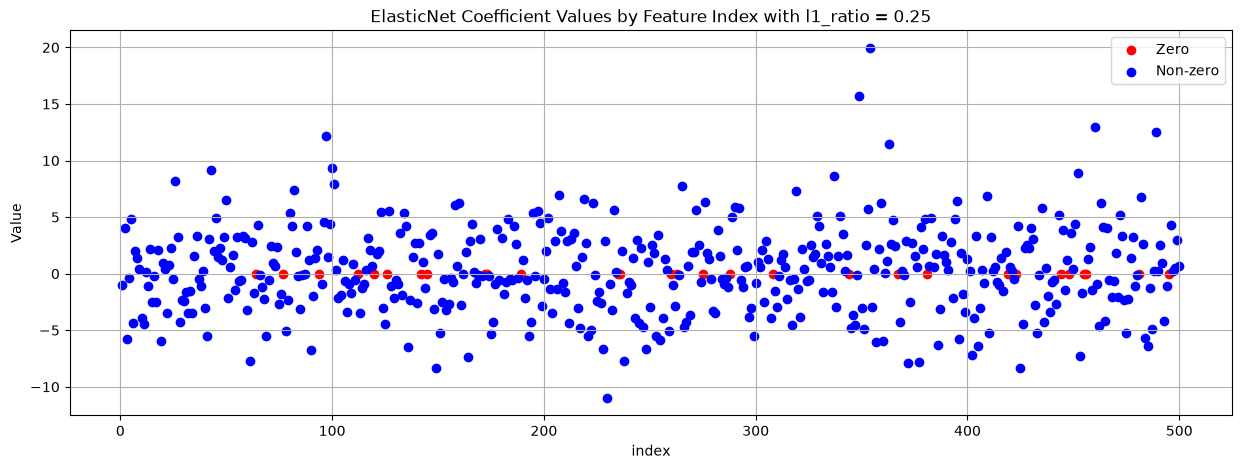

Metrics for i = 0.5:
MAE: 113.71
MSE: 22647.89
RMSE: 150.49
R² Score: 0.03
Number of non zero coefs: 426
Max coef magnitude: 22.3824
Mean coef magnitude: 2.6659


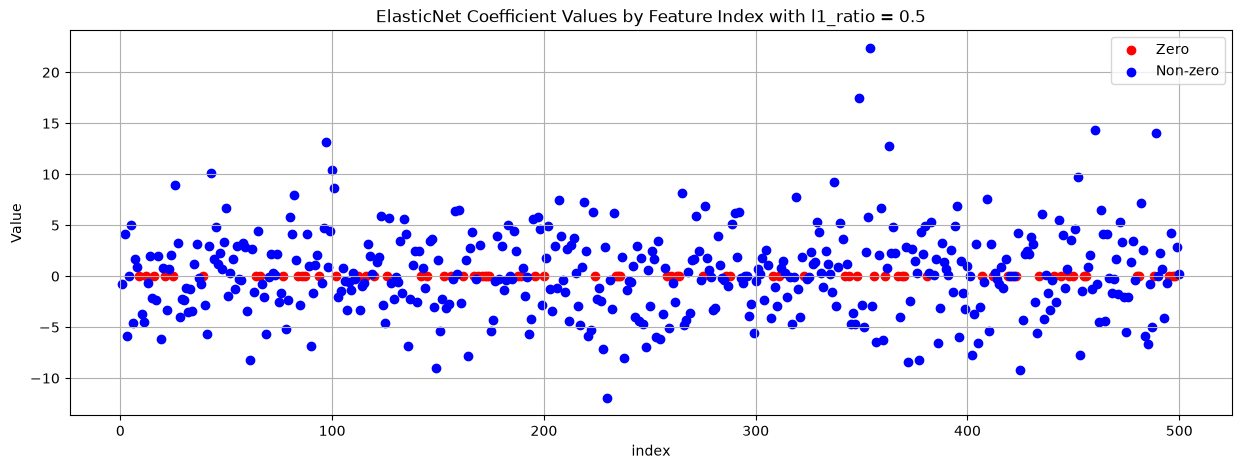

Metrics for i = 0.75:
MAE: 107.35
MSE: 20237.50
RMSE: 142.26
R² Score: 0.14
Number of non zero coefs: 320
Max coef magnitude: 27.8693
Mean coef magnitude: 2.4540


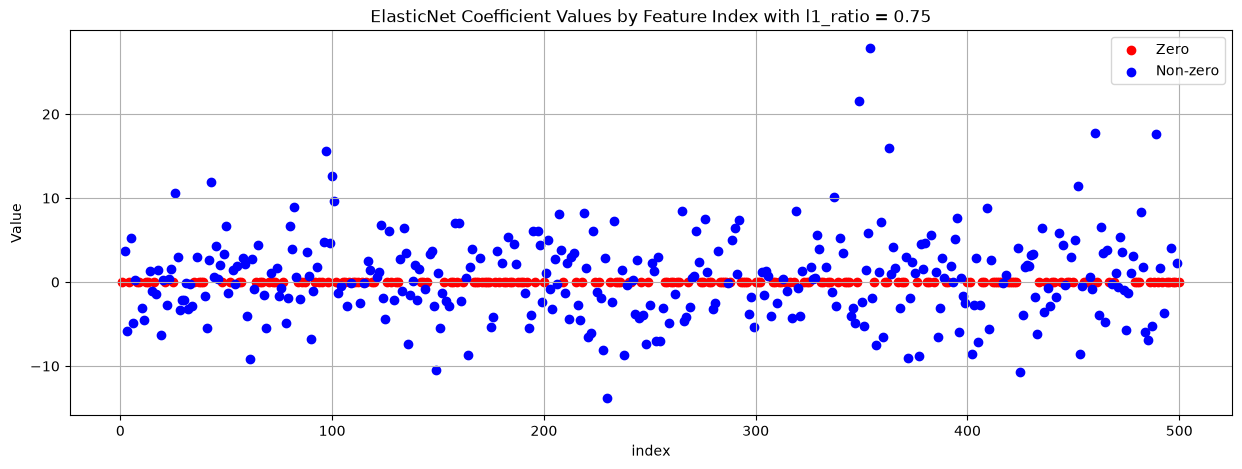

Metrics for i = 1.0:
MAE: 3.90
MSE: 25.28
RMSE: 5.03
R² Score: 1.00
Number of non zero coefs: 23
Max coef magnitude: 97.9885
Mean coef magnitude: 1.2771


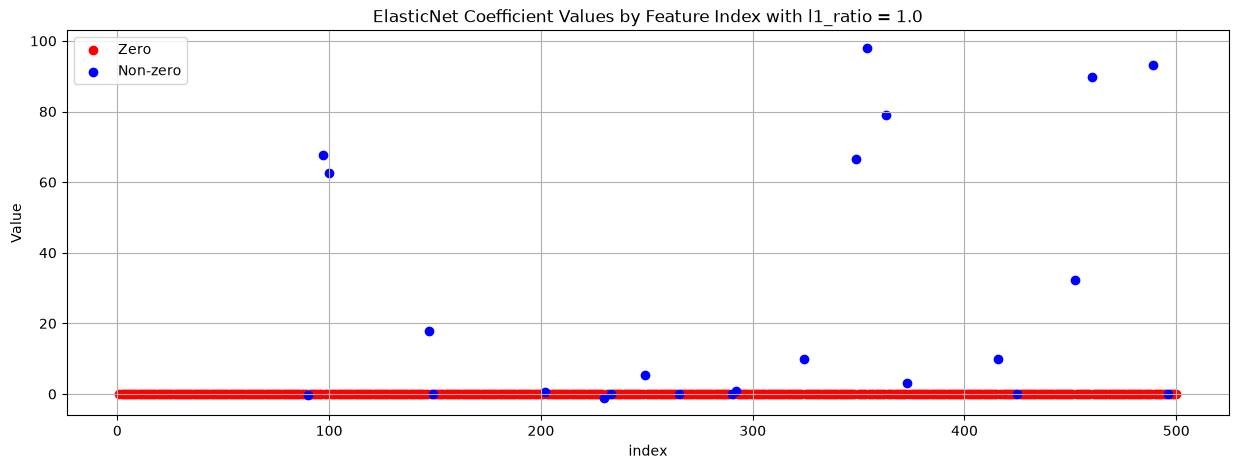

In [10]:
ElasticNet_l1_models = run_elasticnet_l1ratio(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha and l1 ratio for ElasticNet

MAE: 2.10
MSE: 6.27
RMSE: 2.50
R² Score: 1.00
Number of non zero coefs: 43
Max coef magnitude: 98.1414
Mean coef magnitude: 1.2998


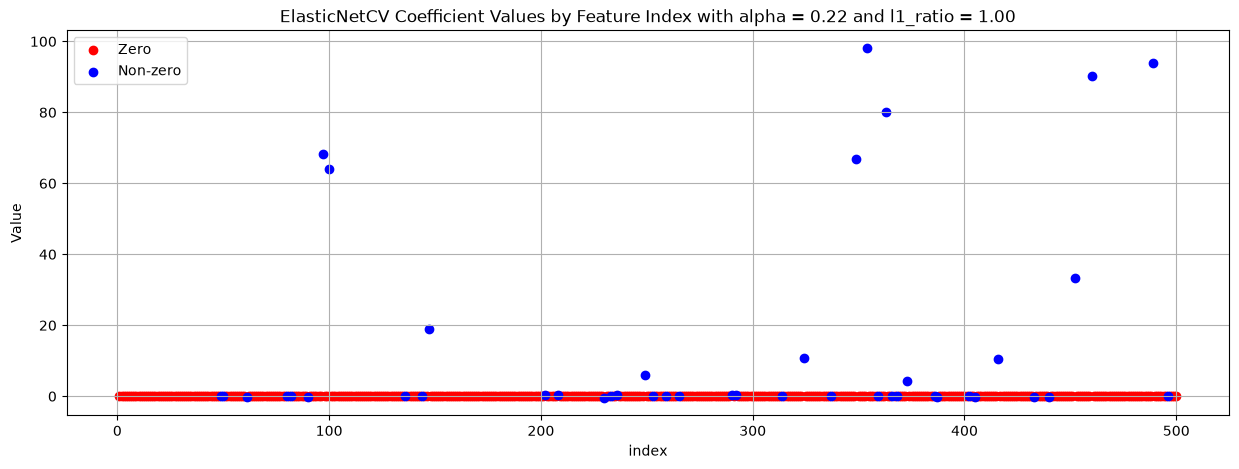

In [11]:
ElasticNet_model = run_elasticnet_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)